# Brief introduction to Python
## Shutao Cao

## Outline
- [Why Python](#Why-Python)
- [Python starter](#Python-starter)
- [Python for scientific computing](#Python-for-scientific-computing)  

### Why Python

<a id='index-1'></a>

[Python](https://www.python.org) is a generic scripting computer language used for many purposes
- System administration
- Web development
- game development  
- multimedia, natural language
- Scientific computing
- Data science and statistics
- Machine Learning, ...

Python is increasingly popular in the scientific community pretty much in all areas. Economists have been rapidly learning to use Python in research and teaching, and it is no stranger to young PhD students and researchers.

The ecosystem of Python developer and user community is huge, it is safe to say that Python is the computer language for everything.

Python is awarded the programming language of the year 2020.

[Python trends](https://www.tiobe.com/tiobe-index/python/)

### Python starter

<a id='index-2'></a>

Python is generic. It is a calcultor to start with, and it is a gigantic system used to run big systems by corporates.

#### Data types

- boolean 
- int, double, complex
- strings
- None

#### Operators

- mathematical
- logical
- bitwise
- membership
- identity
- assignment and in-place operators
- operator precedence

#### Collections

- Sequence containers - list, tuple
- Mapping containers - set, dict
- The [`collections`](https://docs.python.org/2/library/collections.html) module

#### Functions and methods

- Anatomy of a function
- Docstrings
- Class methods

#### Control flow

- if and the ternary operator
- Checking conditions - what evaluates as true/false?
- if-elif-else
- while
- break, continue
- pass

#### Loops and comprehensions

- for, range, enumerate
- lazy and eager evaluation
- list, set, dict comprehensions
- generator expression

#### Packages and namespace

- Modules (file)
- Package (hierarchical modules)
- Namespace and naming conflicts
- Using `import`
- [Batteries included](https://docs.python.org/3/library/index.html)


In [1]:
2+3

5

In [2]:
x = ["Bob", "Alice", "Zack", "Tyler"]
for name in x:
    print(name)

Bob
Alice
Zack
Tyler


In [3]:
"""Anonymous functions are handy"""
fib = [0,1,1,2,3,5,8,13,21,34,55]
results = filter(lambda x: x % 2==0, fib)
for x in results:
    print(x)

0
2
8
34


In [4]:
fib = [0,1,1,2,3,5,8,13,21,34,55]
results2 = [x for x in fib if x % 2 == 0]
for x in results2:
    print(x)

0
2
8
34


In [8]:
"""
this code solve for consumer's utility maximization problem. U(C,l) is Cobb-Douglas, l is leisure, C is consumption
I worked out first-order conditions in equations, translated them to code
"""
import numpy as np
# parameters
shareC = 0.65
sharel = 1.0 - shareC
sigma = 2.0

wage, profit, tax = 0.5, 1.8, 0.5
hmax = 5.5
#---optimal cohices: c/l = w * sharec/sharel
lstar, Cstar=optimalChoice(sharel,shareC,wage,hmax,profit,tax)
# maximized utility under wage
util0 = utilityfun(lstar,Cstar,shareC, sharel, sigma)

print('Optimal C=', Cstar, "optimal l=", lstar)
print('Maximized utility level=', util0)


# utility function
def utilityfun(l,C,shareC, sharel, sigma):
    tmplc = (l**sharel) * (C**shareC)
    return (tmplc**(1.0-sigma) - 1.0)/(1.0-sigma)
# optimal choices
def optimalChoice(sharel,shareC,wage,hmax,profit,tax):
    lstar = (sharel/(sharel+shareC)) *(wage*hmax + profit - tax) / wage
    Cstar = lstar * wage * shareC / sharel
    return lstar,Cstar

Optimal C= 2.6325 optimal l= 2.8349999999999995
Maximized utility level= 0.6298591815260064


## Python for scientific computing

<a id='index-3'></a>

Python is one of the core languages of scientific computing. In fact, it is the modules (libraries) written in Python that have become the essential tools for scientific computing.

Many of the Python modules are translated from numerical libraries written in `C` and `Fortran`.

Its popularity in economics is also beginning to rise, a collaborated effort is [quantecon.org](https://quantecon.org).

We take a bird's-eye view on Python modules for scientific computing

In Pyton, a module is a file that contains python definitions and statements. We need to import them when we need to use them.

[NumPy](http://www.numpy.org/) library is fundamental for many other modules. It is for matrix and array manipulation and operation.

[Scipy](https://www.scipy.org/index.html) is a comprehensive numerical library.

[Pandas](https://pandas.pydata.org) is a package for data processing and analysis, popular but largely because no good substitutes. It is based on `R` data frame.

[Matplotlib](https://matplotlib.org) is a basic (but rich) library for visualization. Some other complements are [Bokeh](https://bokeh.org), [Plotly](https://plotly.com/python/), etc.

[Statsmodels](https://www.statsmodels.org/stable/index.html) is a library for statistical estimation and inference.

[Scikit-learn](https://scikit-learn.org/stable/index.html), a Python machine learning package, mostly for supervised learning. Some other machine learning libraries, such as TensorFlow for neural networks.

### Numpy

In [59]:
import numpy as np                     # convention to name numpy as np in your codes

x = np.array([[1,2,3],[4,5,6]])
print ('x=',x)
for xi in x:
    print('xi=',xi)
y = x.T
print('y=',y)

x= [[1 2 3]
 [4 5 6]]
xi= [1 2 3]
xi= [4 5 6]
y= [[1 4]
 [2 5]
 [3 6]]


In [60]:
a = np.linspace(-np.pi, np.pi, 10)    # Create even grid from -π to π
print('a=', a)

a= [-3.14159265 -2.44346095 -1.74532925 -1.04719755 -0.34906585  0.34906585
  1.04719755  1.74532925  2.44346095  3.14159265]


In [61]:
np.fromfunction(lambda x, y: x*3 + y + 1, (2,3))

array([[1., 2., 3.],
       [4., 5., 6.]])

Solving a system of linear equations:
\begin{align*}3 x_0 + 2 x_1 - x_2 = 9 \\ x_0 - 2 x_1 + 0.5x_2 = 2 \\  5 x_0 +0.2x_1 - 2x_2 = 10 \end{align*}
In matrix, $A x = b$

In [62]:
from numpy import linalg
A = np.array([[3, 2, -1], [1,-2, 0.5], [5,0.2,-2]])
b = np.array([9,2,10])
x = np.linalg.solve(A, b)
print('x=',x)

x= [3.11428571 1.28571429 2.91428571]


### Scipy

Scipy is built on top of Numpy, it includes modules for function interpolation, integration, optimization, linear algebra, Fourier transformation, eignevalues, and more. See [here](https://docs.scipy.org/doc/scipy/reference/index.html) for a complete list.

Example: calculate $ \int_{-0.5}^2 \phi(x) dx $ where $ \phi(x) = \frac{1}{\sqrt{2\pi}} \cdot e^{-x^2/2}$ is the standard normal density function.

In [63]:
from scipy.stats import norm
from scipy.integrate import quad
phi = norm()
y, error = quad(phi.pdf, -1.2, 2)  # Integrate using Gaussian quadrature
print('y=',y)

y= 0.8621801978301126


### Matplotlib
Given data in Numpy arrays, plot 2D or 3D figures, can also create animation.

First thing to look at should be the [anatomy of a figure](https://matplotlib.org/3.3.3/gallery/showcase/anatomy.html)

Example: Standard normal distribution.

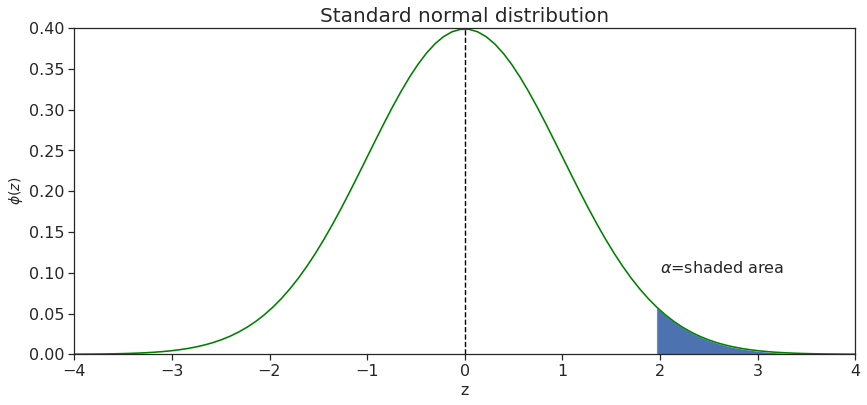

In [64]:
import numpy as np;
from scipy.stats import norm;
import matplotlib.pyplot as plt;
import seaborn;
seaborn.set(style='ticks');
x = np.linspace(norm.ppf(0.0000001),norm.ppf(0.9999999), 120);
pdfx = norm.pdf(x);
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 6), sharey='all');
ax.plot(x,pdfx, color="green", linewidth=1.6, linestyle="-");
ax.fill_betweenx(pdfx,x,x2=1.96, where = x>1.96,interpolate=True);
plt.axvline(x=0.0, color='black', linewidth=1.4,linestyle='--');
plt.text(2.0,.1,'\n$\\alpha$=shaded area',fontsize=16, horizontalalignment='left');
plt.autoscale(enable=True, axis='x', tight=True);
ax.set_title('Standard normal distribution', fontsize=20);
ax.tick_params(axis='y', labelsize=16);
ax.tick_params(axis='x', labelsize=16);
ax.set_xlim([-4,4]);
ax.set_ylim([0.0,0.4]);
plt.xlabel("z", fontsize=16);
ax.set_ylabel('$\phi(z)$', fontsize=14);
#ax.set_aspect('equal')
#fig.tight_layout();

Another example: animating effect of increase in total factor productivity in a static GE model

<video width="832" height="624" controls src="animation_TFPeffect.mp4" />

### Pandas

Pandas is fast, efficient, flexible and well designed. Somehow, its syntax is confusing to me.

But Pandas has been improving.

In [65]:
# Example 1: use pandas to create time series
import pandas as pd
np.random.seed(1234)
data = np.random.randn(5, 2)  # 5x2 matrix of N(0, 1) random draws
dates = pd.date_range('28/12/2010', periods=5)
df = pd.DataFrame(data, columns=('price', 'weight'), index=dates)
print(df)

               price    weight
2010-12-28  0.471435 -1.190976
2010-12-29  1.432707 -0.312652
2010-12-30 -0.720589  0.887163
2010-12-31  0.859588 -0.636524
2011-01-01  0.015696 -2.242685


In [66]:
df.mean()

price     0.411768
weight   -0.699135
dtype: float64

In [67]:
# Example 2: read Canadian labor market condition data from CSV form
cansimid = '14100287'
filename = 'tbl14100287Final3.csv'
lfs = pd.read_csv(filename, index_col=0)
lfs.index = pd.to_datetime(lfs.index)
lfsQtr = lfs.resample('QS-OCT').mean()
lfsQtr = lfsQtr.round(2)
lfsQtr

,emplBothSex,emplFemale,emplFullBothSex,emplFullFemale,emplFullMale,emplMale,emplPartBothSex,emplPartFemale,emplPartMale,emplRateBothSex,emplRateFemale,emplRateMale,labForceBothSex,labForceFemale,labForceMale,participRateBothSex,participRateFemale,participRateMale,populationBothSex,populationFemale,populationMale,unemplBothSex,unemplFemale,unemplMale,unemplRateBothSex,unemplRateFemale,unemplRateMale
ref_date,,,,,,,,,,,,,,,,,,,,,,,,,,,
1976-01-01,9666.90,3566.33,8469.30,2735.10,5734.20,6100.53,1197.57,831.23,366.30,57.23,41.77,73.03,10385.07,3874.13,6510.90,61.47,45.37,77.93,16891.70,8538.53,8353.20,718.17,307.77,410.40,6.93,7.93,6.30
1976-04-01,9737.53,3604.93,8529.63,2756.80,5772.83,6132.60,1207.87,848.10,359.73,57.27,41.93,72.93,10455.67,3917.13,6538.50,61.47,45.57,77.73,17008.10,8599.70,8408.40,718.13,312.23,405.90,6.87,7.97,6.20
1976-07-01,9778.40,3635.07,8562.97,2779.30,5783.70,6143.37,1215.43,855.83,359.67,57.10,42.00,72.60,10531.80,3971.10,6560.70,61.53,45.87,77.53,17121.43,8659.10,8462.33,753.40,336.07,417.33,7.17,8.43,6.37
1976-10-01,9824.70,3673.90,8568.27,2790.33,5777.90,6150.80,1256.43,883.60,372.87,57.07,42.20,72.30,10610.63,4012.40,6598.27,61.63,46.10,77.53,17210.97,8705.67,8505.33,785.97,338.47,447.50,7.43,8.43,6.77
1977-01-01,9869.73,3700.57,8605.30,2810.80,5794.50,6169.17,1264.43,889.73,374.67,57.03,42.27,72.17,10699.63,4059.40,6640.27,61.83,46.40,77.70,17300.70,8752.77,8548.00,829.93,358.83,471.10,7.77,8.83,7.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-07-01,19102.03,9081.50,15495.80,6783.90,8711.87,10020.57,3606.27,2297.57,1308.70,62.00,58.17,65.93,20242.47,9584.50,10658.00,65.70,61.37,70.17,30806.87,15611.33,15195.57,1140.47,503.03,637.43,5.63,5.27,5.97
2019-10-01,19124.53,9102.93,15521.23,6787.10,8734.17,10021.60,3603.27,2315.83,1287.43,61.83,58.10,65.67,20279.37,9612.83,10666.57,65.57,61.33,69.90,30931.17,15671.30,15259.87,1154.90,509.90,645.00,5.70,5.33,6.07
2020-01-01,18842.40,8899.60,15438.27,6697.90,8740.33,9942.83,3404.13,2201.70,1202.47,60.70,56.60,64.93,20110.80,9506.70,10604.13,64.80,60.50,69.23,31032.37,15719.97,15312.40,1268.40,607.10,661.30,6.30,6.43,6.23


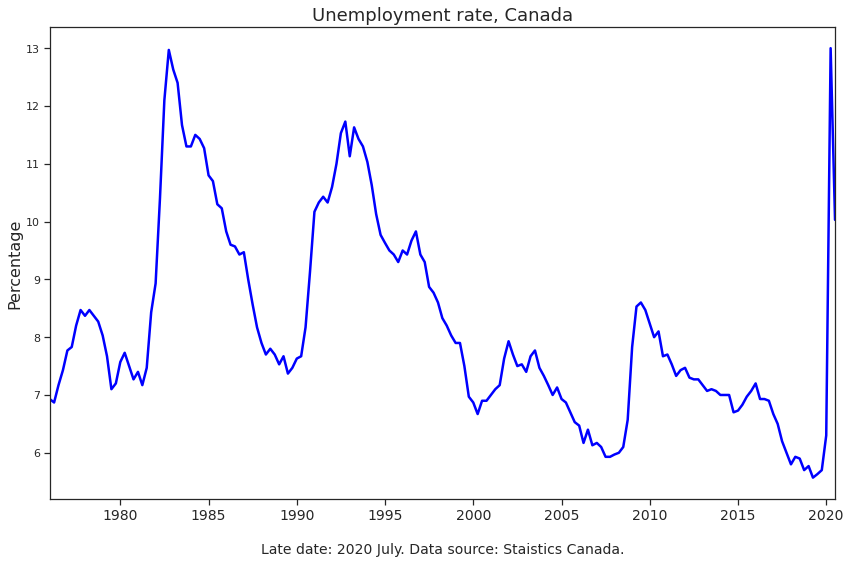

In [68]:
#--unemployment rate, raw
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 8), sharey='all')
ax.plot(lfsQtr['unemplRateBothSex'],color="blue", linewidth=2.5, linestyle="-",label='Unemployment rate')
plt.autoscale(enable=True, axis='x', tight=True)
ax.set_title('Unemployment rate, Canada', fontsize=18)
ax.tick_params(axis='x', labelsize=14)
plt.xlabel("\nLate date: 2020 July. Data source: Staistics Canada.", fontsize=14)
ax.set_ylabel('Percentage', fontsize=16)
fig.tight_layout()
filename = 'UnemploymentRate_Canada.svg'
plt.savefig(filename, dpi=200, format='svg')
plt.show()

### Statsmodels

We read in the Mroz's data on wages from [PSID](https://psidonline.isr.umich.edu), then do a OLS estimation of the wage equation

In [69]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
plt.style.use('seaborn-ticks')

mroz = pd.read_csv("mroz1987.csv")
mroz

,inlf,hours,kidslt6,kidsge6,age,educ,wage,repwage,hushrs,husage,huseduc,huswage,faminc,mtr,motheduc,fatheduc,unem,city,exper,nwifeinc,lwage,expersq
0,1,1610,1,0,32,12,3.3540,2.65,2708,34,12,4.0288,16310,0.7215,12,7,5.0,0,14,10.910060,1.210154,196
1,1,1656,0,2,30,12,1.3889,2.65,2310,30,9,8.4416,21800,0.6615,7,7,11.0,1,5,19.499980,0.328512,25
2,1,1980,1,3,35,12,4.5455,4.04,3072,40,12,3.5807,21040,0.6915,12,7,5.0,0,15,12.039910,1.514138,225
3,1,456,0,3,34,12,1.0965,3.25,1920,53,10,3.5417,7300,0.7815,7,7,5.0,0,6,6.799996,0.092123,36
4,1,1568,1,2,31,14,4.5918,3.60,2000,32,12,10.0000,27300,0.6215,12,14,9.5,1,7,20.100060,1.524272,49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
748,0,0,0,2,40,13,0.0000,0.00,3020,43,16,9.2715,28200,0.6215,10,10,9.5,1,5,28.200000,NaN,25
749,0,0,2,3,31,12,0.0000,0.00,2056,33,12,4.8638,10000,0.7715,12,12,7.5,0,14,10.000000,NaN,196
750,0,0,0,0,43,12,0.0000,0.00,2383,43,12,1.0898,9952,0.7515,10,3,7.5,0,4,9.952000,NaN,16
751,0,0,0,0,60,12,0.0000,0.00,1705,55,8,12.4400,24984,0.6215,12,12,14.0,1,15,24.984000,NaN,225


In [70]:
# OLS estmation of wage equation for husbands
mroz['ones'] = 1.0
X = mroz.loc[:,['ones','huseduc']]
Y = np.log(mroz['huswage'])
#Y = mroz4['huswage']

model = sm.OLS(Y, X)
results = model.fit()
print(" ")
print(results.summary())

# prediction: results.fittedvalues
Yhat = results.params['ones'] + results.params['huseduc']*X['huseduc']

Yhat2 = results.params['ones']*0.7 + results.params['huseduc']*1.4*X['huseduc']


 
                            OLS Regression Results                            
Dep. Variable:                huswage   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     138.3
Date:                Wed, 13 Jan 2021   Prob (F-statistic):           2.03e-29
Time:                        10:35:08   Log-Likelihood:                -598.39
No. Observations:                 753   AIC:                             1201.
Df Residuals:                     751   BIC:                             1210.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
ones           0.9105      0.083     10.943      0

### Networks and Graphs

**NOTE: This subsection is credited to [quantecon.org](https://python-programming.quantecon.org/intro.html)**

Python has many libraries for studying graphs.

One well-known example is [NetworkX](http://networkx.github.io/).
Its features include, among many other things:

- standard graph algorithms for analyzing networks  
- plotting routines  


Here’s some example code that generates and plots a random graph, with node color determined by shortest path length from a central node.

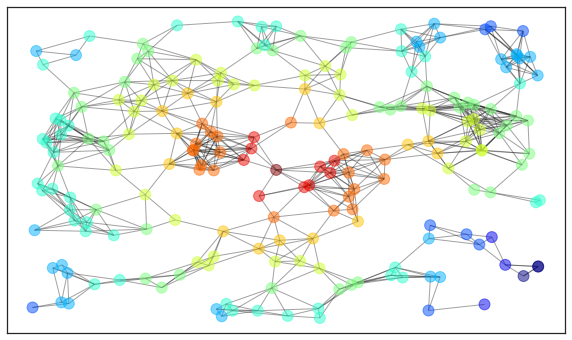

In [71]:
%matplotlib inline
import networkx as nx
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (10,6)
np.random.seed(1234)

# Generate a random graph
p = dict((i, (np.random.uniform(0, 1), np.random.uniform(0, 1)))
         for i in range(200))
g = nx.random_geometric_graph(200, 0.12, pos=p)
pos = nx.get_node_attributes(g, 'pos')

# Find node nearest the center point (0.5, 0.5)
dists = [(x - 0.5)**2 + (y - 0.5)**2 for x, y in list(pos.values())]
ncenter = np.argmin(dists)

# Plot graph, coloring by path length from central node
p = nx.single_source_shortest_path_length(g, ncenter)
plt.figure()
nx.draw_networkx_edges(g, pos, alpha=0.4)
nx.draw_networkx_nodes(g,
                       pos,
                       nodelist=list(p.keys()),
                       node_size=120, alpha=0.5,
                       node_color=list(p.values()),
                       cmap=plt.cm.jet_r)
plt.show()